# MWE 32 - PREGO comparison on synthetic PoreSpy blobs

This notebook reproduces the paper-style comparison idea on synthetic
`256^3` PoreSpy `blobs` volumes. It sends the same binary images through three
extraction backends:

- PoreSpy `snow2`, the established watershed/SNOW-style reference path in
  `voids`
- `prego`, the native PREGO-style seed-based region-growing backend
- `native_maximal_ball`, a separate native extraction reference already used
  elsewhere in this repository

Scientific scope and assumptions:

- the images are synthetic binary blobs, not scanner-derived segmentations
- the notebook compares extracted-network behavior, not direct image physics
- the same `voids` single-phase conductance model and boundary conditions are
  used after extraction, so permeability differences mostly reflect extracted
  topology and geometry
- the PREGO implementation follows the paper's published algorithmic
  description, but it is not a bitwise reproduction of the authors' code
- `256^3` cases are large enough to expose runtime differences and give more
  meaningful network-size distributions, but they are still notebook-scale
  examples rather than a full scaling benchmark

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import porespy as ps

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.graph.metrics import coordination_numbers
from voids.image import construct_spanning_network, has_spanning_cluster
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "mkdocs.yml").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd


def _finite_median(values: np.ndarray) -> float:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return float("nan")
    return float(np.median(finite))


def _finite_mean(values: np.ndarray) -> float:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return float("nan")
    return float(np.mean(finite))


def _diameter_array(container: dict[str, np.ndarray]) -> np.ndarray:
    if "diameter_inscribed" in container:
        return np.asarray(container["diameter_inscribed"], dtype=float)
    if "diameter_equivalent" in container:
        return np.asarray(container["diameter_equivalent"], dtype=float)
    if "radius_inscribed" in container:
        return 2.0 * np.asarray(container["radius_inscribed"], dtype=float)
    return np.asarray([], dtype=float)

In [2]:
project_root = _find_project_root()
output_dir = (
    project_root / "notebooks" / "outputs" / "32_mwe_prego_blobs_backend_comparison"
)
output_dir.mkdir(parents=True, exist_ok=True)

flow_axis = "x"
axis_index = 0
voxel_size = 2.0e-6
fluid = FluidSinglePhase(viscosity=1.0e-3)
bc = PressureBC("inlet_xmin", "outlet_xmax", pin=1.0, pout=0.0)
options = SinglePhaseOptions(conductance_model="valvatne_blunt", solver="direct")

sample_shape = (256, 256, 256)
case_specs = [
    {
        "case": "phi032_b1",
        "shape": sample_shape,
        "porosity": 0.32,
        "blobiness": 1,
        "seed_start": 100,
    },
    {
        "case": "phi040_b1",
        "shape": sample_shape,
        "porosity": 0.40,
        "blobiness": 1,
        "seed_start": 400,
    },
    {
        "case": "phi045_b1",
        "shape": sample_shape,
        "porosity": 0.45,
        "blobiness": 1,
        "seed_start": 500,
    },
]

backend_specs = [
    {
        "backend": "porespy",
        "label": "PoreSpy snow2",
        "extraction_kwargs": {"sigma": 0.4, "r_max": 4},
    },
    {
        "backend": "prego",
        "label": "PREGO",
        "extraction_kwargs": {
            "settings": {
                "r_max": 4,
                "sigma": 0.4,
                "peak_footprint": "cube",
                "distance_map_backend": "scipy",
            },
        },
    },
    {
        "backend": "native_maximal_ball",
        "label": "Native maximal-ball",
        "extraction_kwargs": {
            "distance_map_backend": "scipy",
            "apply_boundary_clipping": False,
            "settings": {"minimal_pore_radius_voxels": 1.0},
        },
    },
]

case_specs

[{'case': 'phi032_b1',
  'shape': (256, 256, 256),
  'porosity': 0.32,
  'blobiness': 1,
  'seed_start': 100},
 {'case': 'phi040_b1',
  'shape': (256, 256, 256),
  'porosity': 0.4,
  'blobiness': 1,
  'seed_start': 400},
 {'case': 'phi045_b1',
  'shape': (256, 256, 256),
  'porosity': 0.45,
  'blobiness': 1,
  'seed_start': 500}]

## Generate spanning PoreSpy blob images

The PREGO paper used PoreSpy `blobs` images for its segmentation performance
scaling comparison. Here each case is generated directly from
`porespy.generators.blobs`, then accepted only if it has a face-connected void
path across the selected flow axis. PREGO uses a cubic local-maximum filter for
seed detection by default; set `peak_footprint="sphere"` in the settings above
to recover the slower PoreSpy/SNOW spherical peak-filter compatibility path.

In [3]:
images: dict[str, np.ndarray] = {}
image_rows: list[dict[str, object]] = []

for spec in case_specs:
    accepted_seed: int | None = None
    accepted_image: np.ndarray | None = None
    for seed in range(int(spec["seed_start"]), int(spec["seed_start"]) + 50):
        candidate = ps.generators.blobs(
            shape=list(spec["shape"]),
            porosity=float(spec["porosity"]),
            blobiness=int(spec["blobiness"]),
            seed=seed,
        )
        if has_spanning_cluster(candidate, axis_index=axis_index):
            accepted_seed = seed
            accepted_image = np.asarray(candidate, dtype=bool)
            break
    if accepted_image is None or accepted_seed is None:
        raise RuntimeError(
            f"Could not generate a spanning blob image for {spec['case']}"
        )

    case_name = str(spec["case"])
    images[case_name] = accepted_image
    image_rows.append(
        {
            **spec,
            "seed_used": accepted_seed,
            "phi_image": float(accepted_image.mean()),
            "spans_x": has_spanning_cluster(accepted_image, axis_index=0),
            "spans_y": has_spanning_cluster(accepted_image, axis_index=1),
            "spans_z": has_spanning_cluster(accepted_image, axis_index=2),
        }
    )

image_df = pd.DataFrame(image_rows)
image_df

,case,shape,porosity,blobiness,seed_start,seed_used,phi_image,spans_x,spans_y,spans_z
0,phi032_b1,"(256, 256, 256)",0.32,1,100,100,0.32,True,True,True
1,phi040_b1,"(256, 256, 256)",0.40,1,400,400,0.40,True,True,True
2,phi045_b1,"(256, 256, 256)",0.45,1,500,500,0.45,True,True,True


## Extract, solve, and summarize

The metrics below follow the paper's comparison categories: pore count, throat
count, pore/throat size, coordination number, porosity, permeability, and CPU
time. The reported CPU time is notebook-level wall time for extraction or
solve on these small cases; it should not be interpreted as the large-volume
scaling result from the paper.

In [4]:
rows: list[dict[str, object]] = []
constructions: dict[tuple[str, str], object] = {}
solve_results: dict[tuple[str, str], object] = {}

for case_name, image in images.items():
    for backend_spec in backend_specs:
        extraction_start = time.perf_counter()
        construction = construct_spanning_network(
            backend=str(backend_spec["backend"]),
            phases=image.astype(int),
            voxel_size=voxel_size,
            flow_axis=flow_axis,
            extraction_kwargs=dict(backend_spec["extraction_kwargs"]),
            provenance_notes={
                "benchmark_kind": "prego_blobs_backend_comparison",
                "synthetic_generator": "porespy.generators.blobs",
                "case": case_name,
            },
        )
        extraction_seconds = time.perf_counter() - extraction_start

        solve_start = time.perf_counter()
        result = solve(
            construction.net,
            fluid=fluid,
            bc=bc,
            axis=flow_axis,
            options=options,
        )
        solve_seconds = time.perf_counter() - solve_start

        net = construction.net
        pore_diameter = _diameter_array(net.pore)
        throat_diameter = _diameter_array(net.throat)
        coordination = coordination_numbers(net)

        rows.append(
            {
                "case": case_name,
                "backend": backend_spec["backend"],
                "backend_label": backend_spec["label"],
                "backend_version": construction.backend_version,
                "shape": str(image.shape),
                "phi_image": float(image.mean()),
                "phi_abs": float(absolute_porosity(net)),
                "phi_eff_x": float(effective_porosity(net, axis=flow_axis)),
                "Np": int(net.Np),
                "Nt": int(net.Nt),
                "mean_coordination": _finite_mean(coordination),
                "median_pore_diameter_m": _finite_median(pore_diameter),
                "median_throat_diameter_m": _finite_median(throat_diameter),
                "Kx_m2": float(result.permeability[flow_axis]),
                "Q_m3_s": float(result.total_flow_rate),
                "mass_balance_error": float(result.mass_balance_error),
                "extraction_seconds": float(extraction_seconds),
                "solve_seconds": float(solve_seconds),
            }
        )
        constructions[(case_name, str(backend_spec["backend"]))] = construction
        solve_results[(case_name, str(backend_spec["backend"]))] = result

summary_df = pd.DataFrame(rows)

reference = summary_df.loc[
    summary_df["backend"] == "porespy", ["case", "Kx_m2", "Np", "Nt"]
]
reference = reference.rename(
    columns={"Kx_m2": "Kx_snow2_m2", "Np": "Np_snow2", "Nt": "Nt_snow2"}
)
summary_df = summary_df.merge(reference, on="case", how="left")
summary_df["Kx_ratio_to_snow2"] = summary_df["Kx_m2"] / summary_df["Kx_snow2_m2"]
summary_df["Np_ratio_to_snow2"] = summary_df["Np"] / summary_df["Np_snow2"]
summary_df["Nt_ratio_to_snow2"] = summary_df["Nt"] / summary_df["Nt_snow2"]

display_columns = [
    "case",
    "backend_label",
    "phi_image",
    "phi_abs",
    "phi_eff_x",
    "Np",
    "Nt",
    "mean_coordination",
    "median_pore_diameter_m",
    "median_throat_diameter_m",
    "Kx_m2",
    "Kx_ratio_to_snow2",
    "extraction_seconds",
]
summary_df.loc[:, display_columns]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,case,backend_label,phi_image,phi_abs,phi_eff_x,Np,Nt,mean_coordination,median_pore_diameter_m,median_throat_diameter_m,Kx_m2,Kx_ratio_to_snow2,extraction_seconds
0,phi032_b1,PoreSpy snow2,0.32,0.334429,0.334429,1237,1998,3.230396,0.000020,0.000022,1.048927e-12,1.000000,10.602591
1,phi032_b1,PREGO,0.32,0.317970,0.317970,769,1746,4.540962,0.000029,0.000022,1.428455e-12,1.361825,7.236538
2,phi032_b1,Native maximal-ball,0.32,0.317970,0.317970,650,1270,3.907692,0.000032,0.000018,3.608839e-12,3.440506,12.486288
3,phi040_b1,PoreSpy snow2,0.40,0.419214,0.419214,1401,2568,3.665953,0.000020,0.000023,2.518224e-12,1.000000,9.952713
4,phi040_b1,PREGO,0.40,0.398919,0.398919,861,2350,5.458769,0.000030,0.000023,3.021492e-12,1.199850,7.537757
5,phi040_b1,Native maximal-ball,0.40,0.398919,0.398919,688,1578,4.587209,0.000035,0.000019,8.241014e-12,3.272550,16.117709
6,phi045_b1,PoreSpy snow2,0.45,0.472200,0.472200,1442,2834,3.930652,0.000020,0.000025,4.326223e-12,1.000000,10.299894
7,phi045_b1,PREGO,0.45,0.449695,0.449695,858,2601,6.062937,0.000032,0.000024,4.936248e-12,1.141006,8.180918
8,phi045_b1,Native maximal-ball,0.45,0.449695,0.449695,645,1669,5.175194,0.000038,0.000020,1.583461e-11,3.660146,17.867414


## Representative segmentation input

These are the binary images passed to all backends. The extraction backends
differ only after this point.

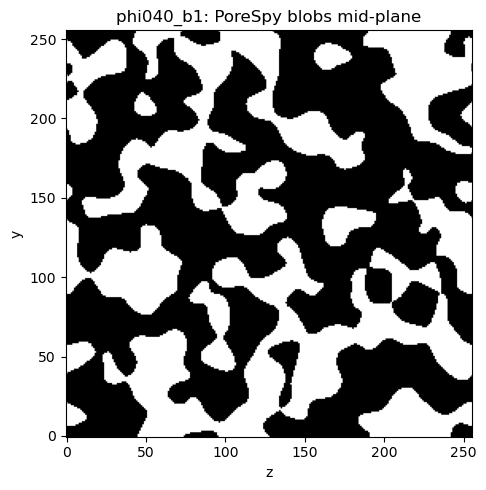

Saved: /Users/dtvolpatto/Work/voids/notebooks/outputs/32_mwe_prego_blobs_backend_comparison/representative_blobs_slice.png


In [5]:
representative_case = "phi040_b1"
representative_image = images[representative_case]
mid = representative_image.shape[0] // 2

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.imshow(representative_image[mid, :, :], cmap="gray", origin="lower")
ax.set_title(f"{representative_case}: PoreSpy blobs mid-plane")
ax.set_xlabel("z")
ax.set_ylabel("y")
plt.tight_layout()
input_slice_path = output_dir / "representative_blobs_slice.png"
fig.savefig(input_slice_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", input_slice_path)

## Backend-level comparisons

PREGO in this notebook is allowed to be coarser than `snow2`: the paper
itself reports differences in pore and throat sizes, coordination number, and
contact areas. The important scientific question is whether those differences
are stable and whether transport-relevant quantities remain acceptable for the
intended application.

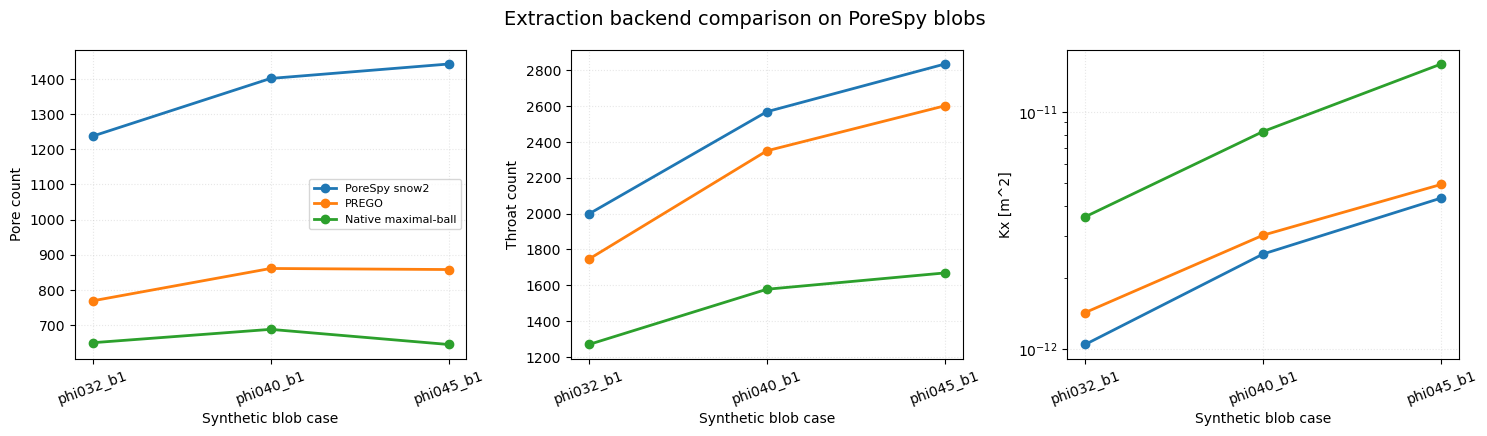

Saved: /Users/dtvolpatto/Work/voids/notebooks/outputs/32_mwe_prego_blobs_backend_comparison/backend_counts_and_permeability.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True)

for backend_label, group in summary_df.groupby("backend_label", sort=False):
    axes[0].plot(
        group["case"], group["Np"], marker="o", linewidth=2, label=backend_label
    )
    axes[1].plot(
        group["case"], group["Nt"], marker="o", linewidth=2, label=backend_label
    )
    axes[2].plot(
        group["case"], group["Kx_m2"], marker="o", linewidth=2, label=backend_label
    )

axes[0].set_ylabel("Pore count")
axes[1].set_ylabel("Throat count")
axes[2].set_ylabel("Kx [m^2]")
axes[2].set_yscale("log")
for ax in axes:
    ax.set_xlabel("Synthetic blob case")
    ax.grid(alpha=0.3, linestyle=":")
    ax.tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=8)
fig.suptitle("Extraction backend comparison on PoreSpy blobs", fontsize=14)
plt.tight_layout()
comparison_path = output_dir / "backend_counts_and_permeability.png"
fig.savefig(comparison_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", comparison_path)

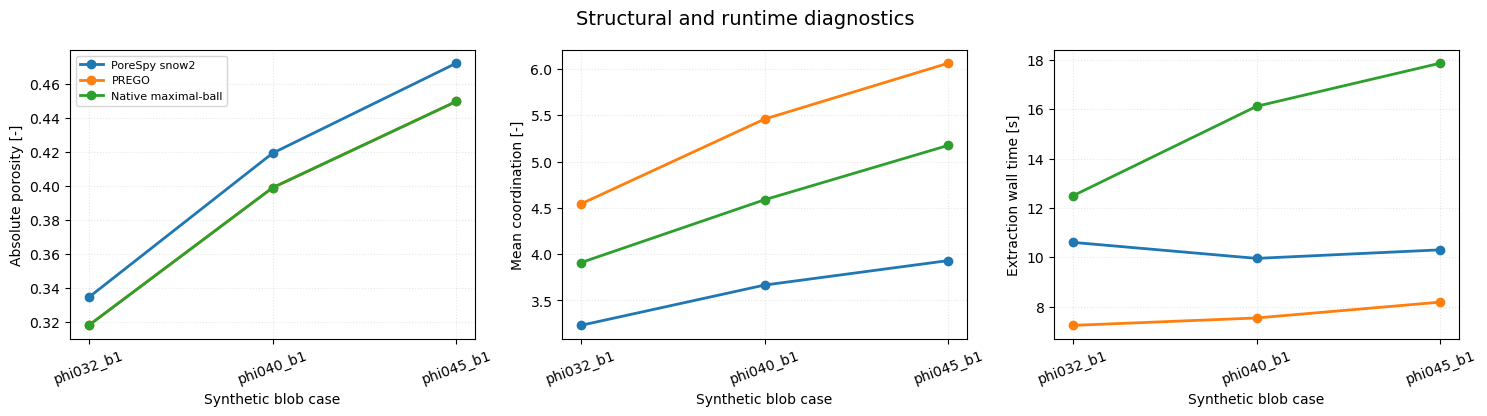

Saved: /Users/dtvolpatto/Work/voids/notebooks/outputs/32_mwe_prego_blobs_backend_comparison/backend_structural_runtime_diagnostics.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)

for backend_label, group in summary_df.groupby("backend_label", sort=False):
    axes[0].plot(
        group["case"], group["phi_abs"], marker="o", linewidth=2, label=backend_label
    )
    axes[1].plot(
        group["case"],
        group["mean_coordination"],
        marker="o",
        linewidth=2,
        label=backend_label,
    )
    axes[2].plot(
        group["case"],
        group["extraction_seconds"],
        marker="o",
        linewidth=2,
        label=backend_label,
    )

axes[0].set_ylabel("Absolute porosity [-]")
axes[1].set_ylabel("Mean coordination [-]")
axes[2].set_ylabel("Extraction wall time [s]")
for ax in axes:
    ax.set_xlabel("Synthetic blob case")
    ax.grid(alpha=0.3, linestyle=":")
    ax.tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=8)
fig.suptitle("Structural and runtime diagnostics", fontsize=14)
plt.tight_layout()
diagnostic_path = output_dir / "backend_structural_runtime_diagnostics.png"
fig.savefig(diagnostic_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", diagnostic_path)

## Representative size distributions

The paper compares pore diameter, throat diameter, coordination number, and
pore-to-pore spacing. Here we show the first three directly from the
canonical `voids.Network` fields for the representative case.

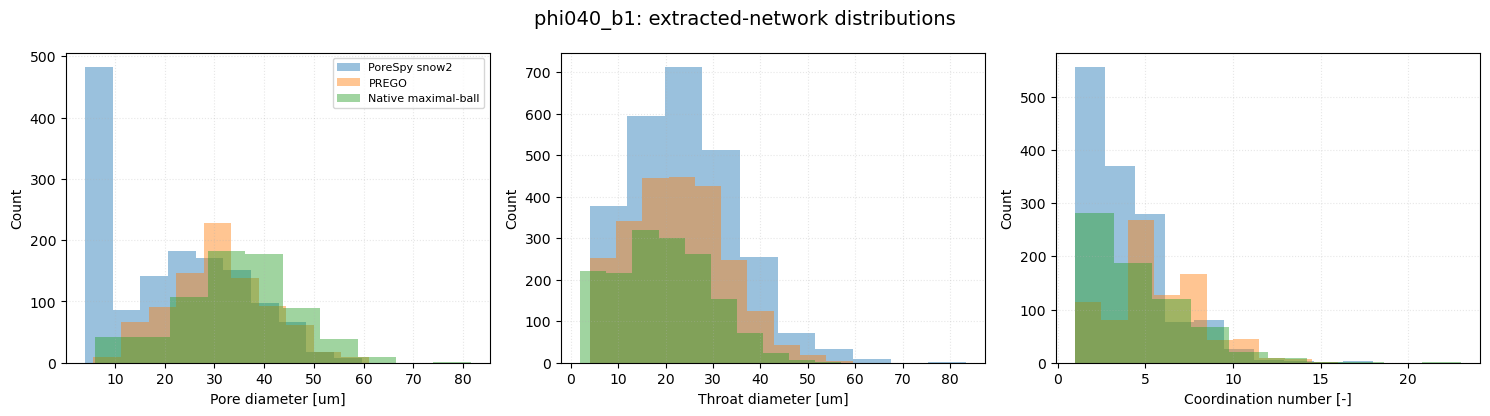

Saved: /Users/dtvolpatto/Work/voids/notebooks/outputs/32_mwe_prego_blobs_backend_comparison/representative_backend_distributions.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for backend_spec in backend_specs:
    backend = str(backend_spec["backend"])
    label = str(backend_spec["label"])
    net = constructions[(representative_case, backend)].net
    pore_diameter_um = 1.0e6 * _diameter_array(net.pore)
    throat_diameter_um = 1.0e6 * _diameter_array(net.throat)
    coordination = coordination_numbers(net)

    if pore_diameter_um.size:
        axes[0].hist(
            pore_diameter_um[np.isfinite(pore_diameter_um)], alpha=0.45, label=label
        )
    if throat_diameter_um.size:
        axes[1].hist(
            throat_diameter_um[np.isfinite(throat_diameter_um)], alpha=0.45, label=label
        )
    if coordination.size:
        axes[2].hist(coordination[np.isfinite(coordination)], alpha=0.45, label=label)

axes[0].set_xlabel("Pore diameter [um]")
axes[1].set_xlabel("Throat diameter [um]")
axes[2].set_xlabel("Coordination number [-]")
for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3, linestyle=":")
axes[0].legend(fontsize=8)
fig.suptitle(f"{representative_case}: extracted-network distributions", fontsize=14)
plt.tight_layout()
distribution_path = output_dir / "representative_backend_distributions.png"
fig.savefig(distribution_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", distribution_path)

## Save tabular outputs

The CSV files are useful for checking whether future PREGO changes move
structural or permeability metrics.

In [9]:
summary_csv = output_dir / "prego_blobs_backend_summary.csv"
image_csv = output_dir / "prego_blobs_image_summary.csv"
summary_df.to_csv(summary_csv, index=False)
image_df.to_csv(image_csv, index=False)
print("Saved:", summary_csv)
print("Saved:", image_csv)

Saved: /Users/dtvolpatto/Work/voids/notebooks/outputs/32_mwe_prego_blobs_backend_comparison/prego_blobs_backend_summary.csv
Saved: /Users/dtvolpatto/Work/voids/notebooks/outputs/32_mwe_prego_blobs_backend_comparison/prego_blobs_image_summary.csv


In [10]:
ratio_table = summary_df.pivot(
    index="case", columns="backend_label", values="Kx_ratio_to_snow2"
)
count_table = summary_df.pivot(
    index="case", columns="backend_label", values="Np_ratio_to_snow2"
)

print("Kx ratios relative to PoreSpy snow2:")
display(ratio_table)

print("Pore-count ratios relative to PoreSpy snow2:")
display(count_table)

max_mass_balance_error = float(summary_df["mass_balance_error"].abs().max())
print(f"Max absolute mass-balance error: {max_mass_balance_error:.3e}")

if max_mass_balance_error < 1.0e-8:
    print(
        "All backend solves satisfy the mass-balance tolerance used in this notebook."
    )
else:
    print(
        "At least one backend solve has a large mass-balance residual; inspect before using Kx."
    )

Kx ratios relative to PoreSpy snow2:


backend_label,Native maximal-ball,PREGO,PoreSpy snow2
case,,,
phi032_b1,3.440506,1.361825,1.0
phi040_b1,3.272550,1.199850,1.0
phi045_b1,3.660146,1.141006,1.0


Pore-count ratios relative to PoreSpy snow2:


backend_label,Native maximal-ball,PREGO,PoreSpy snow2
case,,,
phi032_b1,0.525465,0.621665,1.0
phi040_b1,0.491078,0.614561,1.0
phi045_b1,0.447295,0.595007,1.0


Max absolute mass-balance error: 3.181e-26
All backend solves satisfy the mass-balance tolerance used in this notebook.
